In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

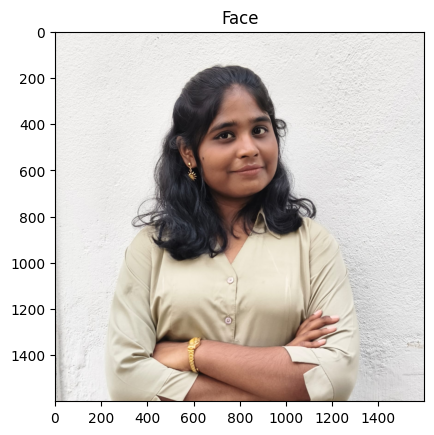

In [34]:
faceImage = cv2.imread('myimage.jpeg')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")

In [36]:
faceImage.shape

(1600, 1600, 3)

Text(0.5, 1.0, 'glassPNG')

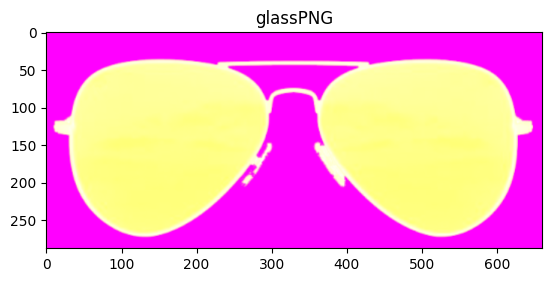

In [38]:
glassPNG = cv2.imread('glass.png',-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

In [39]:
glassPNG = cv2.resize(glassPNG,(190,50))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(50, 190, 4)


In [40]:
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]

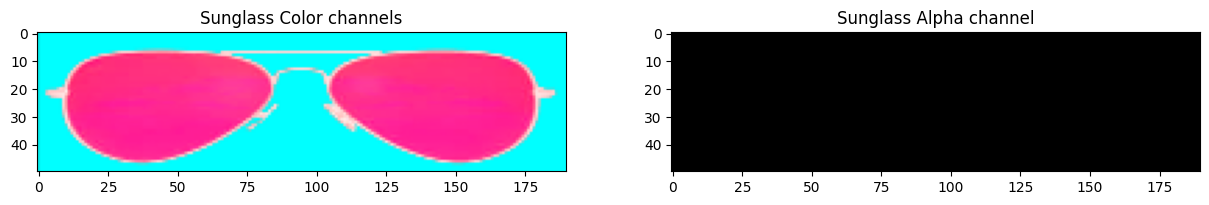

In [41]:
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

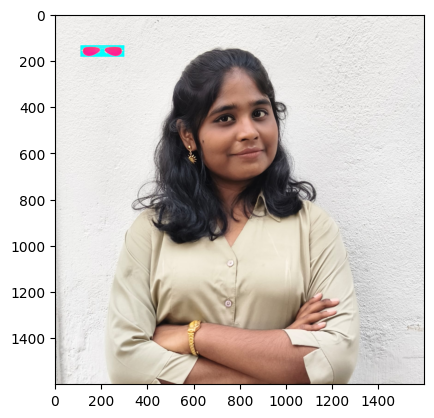

In [42]:
faceWithGlassesNaive = faceImage.copy()

# Replace the eye region with the sunglass image
faceWithGlassesNaive[135:185,110:300]=glassBGR

plt.imshow(faceWithGlassesNaive[...,::-1])

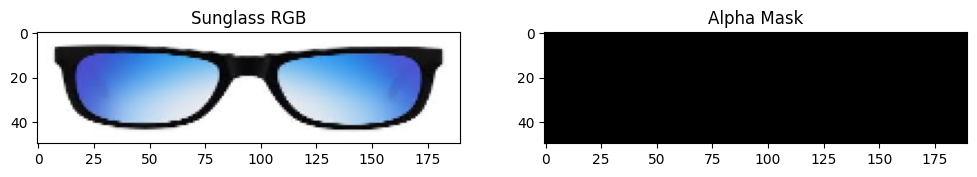

In [23]:
plt.figure(figsize=[12,5])

plt.subplot(121)
plt.imshow(glassBGR[:,:,::-1])
plt.title("Sunglass RGB")

plt.subplot(122)
plt.imshow(glassMask1, cmap='gray')
plt.title("Alpha Mask")

plt.show()

In [25]:
glassMask = cv2.merge((glassMask1, glassMask1, glassMask1))

# Convert mask values from [0,255] to [0,1]
glassMask = glassMask / 255.0

# --------------------------------------------
# STEP 7 : COPY FACE IMAGE
# --------------------------------------------

faceWithGlasses = faceImage.copy()

In [26]:
y1 = 135
y2 = 185

x1 = 110
x2 = 300

In [28]:
# Extract eye region
eyeROI = faceWithGlasses[y1:y2, x1:x2]

# Convert to float
eyeROI = eyeROI.astype(float)
glassBGR = glassBGR.astype(float)

# Create masked regions
maskedEye = cv2.multiply(eyeROI, (1 - glassMask))
maskedGlass = cv2.multiply(glassBGR, glassMask)

# Combine both
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Convert back to uint8
eyeRoiFinal = eyeRoiFinal.astype(np.uint8)

# Place final ROI
faceWithGlasses[y1:y2, x1:x2] = eyeRoiFinal

In [31]:
faceWithGlasses[y1:y2, x1:x2] = eyeRoiFinal
faceImageRGB = cv2.cvtColor(faceImage, cv2.COLOR_BGR2RGB)
finalImage = cv2.cvtColor(faceWithGlasses, cv2.COLOR_BGR2RGB)

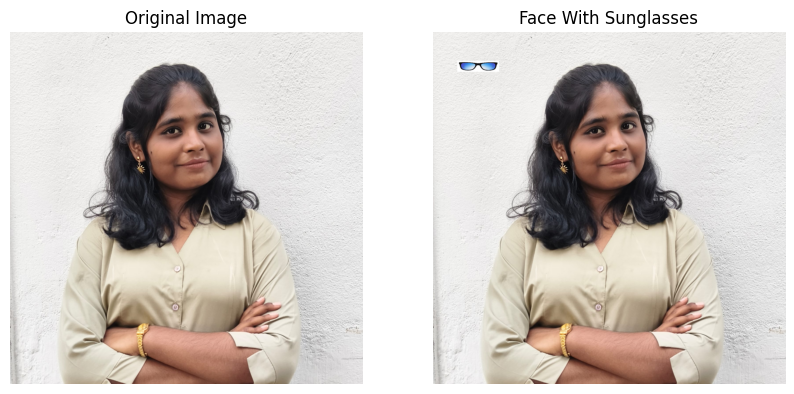

In [32]:

plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
plt.imshow(faceImageRGB)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(finalImage)
plt.title("Face With Sunglasses")
plt.axis('off')

plt.show()

Text(0.5, 1.0, 'Augmented Eye and Sunglass')

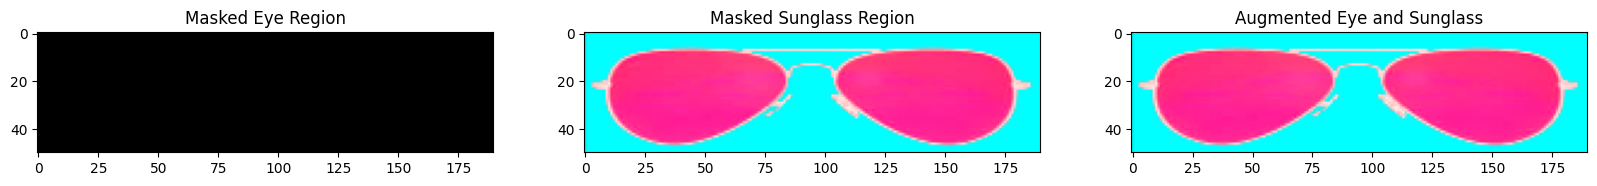

In [43]:

# Make the dimensions of the mask same as the input image.
# Since Face Image is a 3-channel image, we create a 3 channel image for the mask
glassMask = cv2.merge((glassMask1,glassMask1,glassMask1))

# Make the values [0,1] since we are using arithmetic operations
glassMask = np.uint8(glassMask/255)

# Make a copy
faceWithGlassesArithmetic = faceImage.copy()

# Get the eye region from the face image
eyeROI= faceWithGlassesArithmetic[135:185,110:300]

# Use the mask to create the masked eye region
maskedEye = cv2.multiply(eyeROI,(1-  glassMask ))

# Use the mask to create the masked sunglass region
maskedGlass = cv2.multiply(glassBGR,glassMask)

# Combine the Sunglass in the Eye Region to get the augmented image
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Display the intermediate results
plt.figure(figsize=[20,20])
plt.subplot(131);plt.imshow(maskedEye[...,::-1]);plt.title("Masked Eye Region")
plt.subplot(132);plt.imshow(maskedGlass[...,::-1]);plt.title("Masked Sunglass Region")
plt.subplot(133);plt.imshow(eyeRoiFinal[...,::-1]);plt.title("Augmented Eye and Sunglass")

Text(0.5, 1.0, 'With Sunglasses')

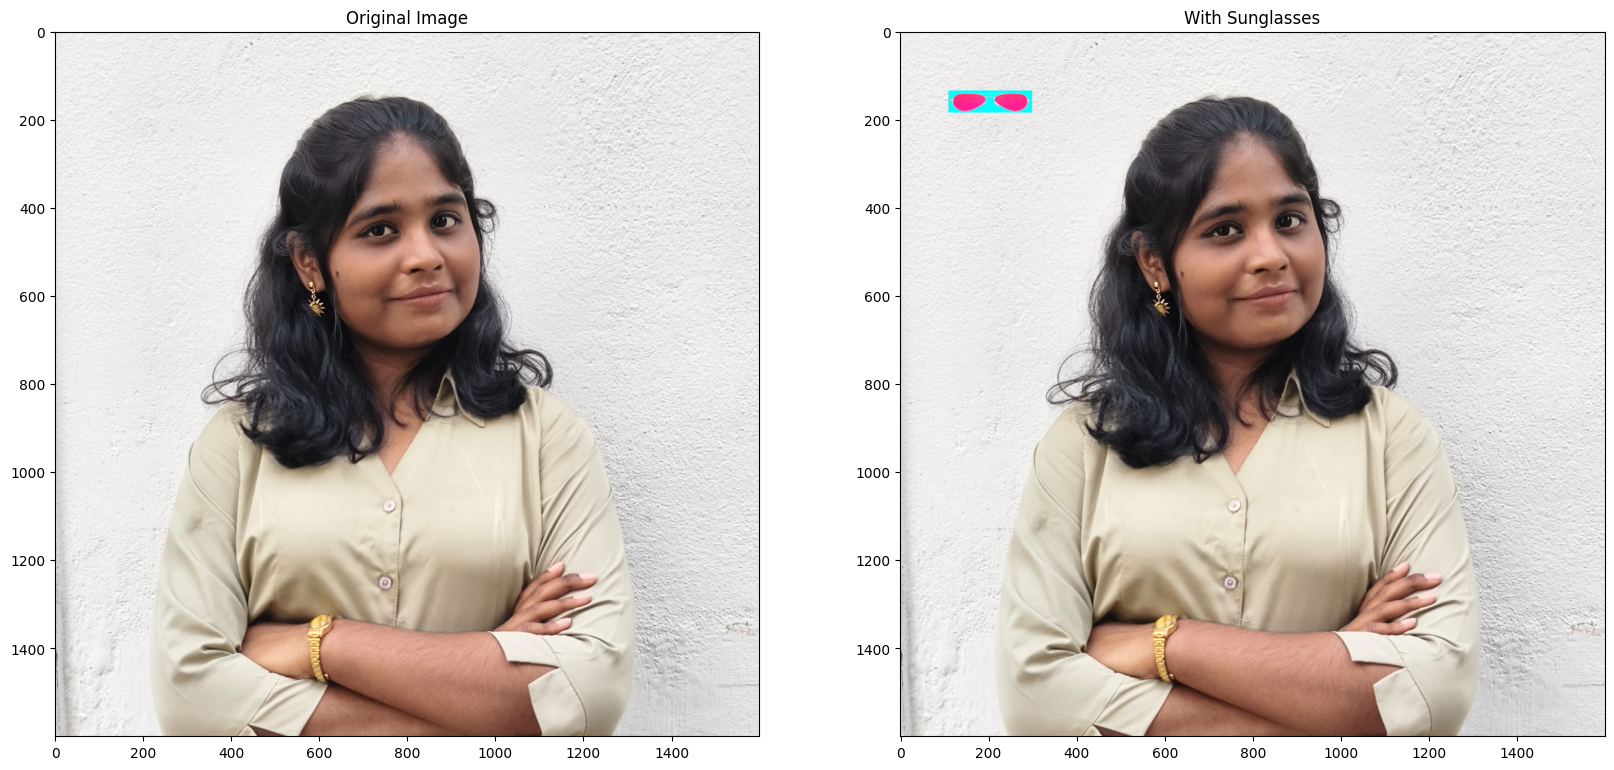

In [44]:
# Replace the eye ROI with the output from the previous section
faceWithGlassesArithmetic[135:185,110:300]=eyeRoiFinal

# Display the final result
plt.figure(figsize=[20,20]);
plt.subplot(121);plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image");
plt.subplot(122);plt.imshow(faceWithGlassesArithmetic[:,:,::-1]);plt.title("With Sunglasses")